In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

os.listdir('/content/drive/MyDrive')

['Black and White Modern Tech Company Presentation_20250729_104853_0000.pdf',
 'Colab Notebooks',
 'IMG-20260223-WA0059 (1).jpg',
 'IMG-20260223-WA0059.jpg',
 '1000021828 (1).pdf',
 '1000021828.pdf',
 '1000021826.pdf',
 'project.drawio.png',
 'project.drawio.pdf',
 'project.drawio',
 'IMG_20260717_093628.jpg',
 'archive (15)']

In [6]:
import os

dataset_path = '/content/drive/MyDrive/archive (15)'

print("Dataset contents:")
print(os.listdir(dataset_path))

Dataset contents:
['data']


In [7]:
import os

dataset_path = '/content/drive/MyDrive/archive (15)/data'

print("Dataset contents:")
print(os.listdir(dataset_path))

Dataset contents:
['README.md', 'YOLO-conversion-script.py', 'annotations_coco.json', 'COCO-conversion-script.py', 'labels-YOLO', 'images', 'labels']


In [8]:
import shutil
import os

source = '/content/drive/MyDrive/archive (15)/data'
destination = '/content/road_damage_data'

shutil.copytree(source, destination, dirs_exist_ok=True)

print("Dataset copied successfully!")
print(os.listdir(destination))

Dataset copied successfully!
['COCO-conversion-script.py', 'labels', 'YOLO-conversion-script.py', 'README.md', 'annotations_coco.json', 'images', 'labels-YOLO']


In [9]:
dataset_path = '/content/road_damage_data'

images_path = os.path.join(dataset_path, 'images')
labels_path = os.path.join(dataset_path, 'labels')

# Get image and label files
image_files = os.listdir(images_path)
label_files = os.listdir(labels_path)

# Keep only relevant files
image_files = [f for f in image_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
label_files = [f for f in label_files if f.lower().endswith('.txt')]

print("Total images :", len(image_files))
print("Total labels :", len(label_files))

Total images : 2025
Total labels : 2009


In [10]:
from collections import Counter
import os

class_counts = Counter()

for label_file in label_files:
    label_path = os.path.join(labels_path, label_file)

    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

print("Damage instance distribution:")
print("-----------------------------")

for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

Damage instance distribution:
-----------------------------
Class 0: 1261
Class 1: 2519
Class 2: 957


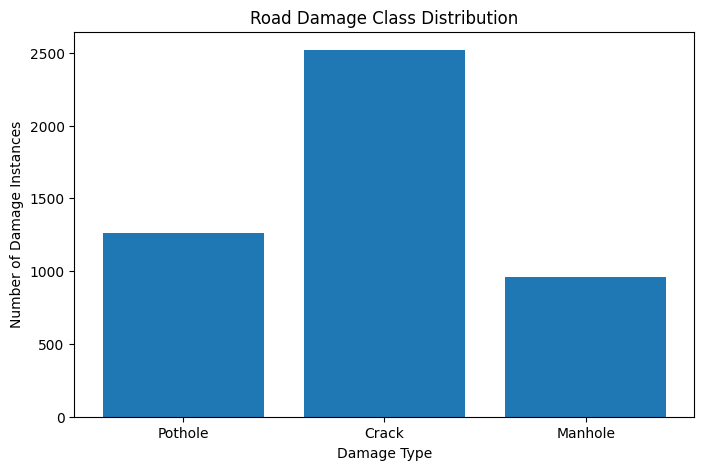

In [11]:
import matplotlib.pyplot as plt

classes = ['Pothole', 'Crack', 'Manhole']
counts = [
    class_counts[0],
    class_counts[1],
    class_counts[2]
]

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)

plt.title('Road Damage Class Distribution')
plt.xlabel('Damage Type')
plt.ylabel('Number of Damage Instances')

plt.show()

In [12]:
from collections import Counter
import os

damage_count_per_image = []

for label_file in label_files:
    label_path = os.path.join(labels_path, label_file)

    with open(label_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    damage_count_per_image.append(len(lines))

# Count how many images have 1 damage, 2 damages, etc.
damage_distribution = Counter(damage_count_per_image)

print("Damages per image:")
print("------------------")

for number_of_damages, number_of_images in sorted(damage_distribution.items()):
    print(
        f"{number_of_damages} damage(s) → "
        f"{number_of_images} image(s)"
    )

Damages per image:
------------------
1 damage(s) → 722 image(s)
2 damage(s) → 564 image(s)
3 damage(s) → 346 image(s)
4 damage(s) → 203 image(s)
5 damage(s) → 84 image(s)
6 damage(s) → 52 image(s)
7 damage(s) → 19 image(s)
8 damage(s) → 9 image(s)
9 damage(s) → 5 image(s)
10 damage(s) → 2 image(s)
11 damage(s) → 2 image(s)
13 damage(s) → 1 image(s)


In [13]:
from collections import Counter
import os

# Store the classes present in each image
classes_per_image = []

for label_file in label_files:
    label_path = os.path.join(labels_path, label_file)

    classes = set()

    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line:
                class_id = int(line.split()[0])
                classes.add(class_id)

    classes_per_image.append(classes)

# Count images based on number of different classes
class_count_distribution = Counter(len(classes) for classes in classes_per_image)

print("Number of different damage classes per image:")
print("---------------------------------------------")

for num_classes, num_images in sorted(class_count_distribution.items()):
    print(f"{num_classes} class(es) → {num_images} image(s)")

Number of different damage classes per image:
---------------------------------------------
1 class(es) → 1205 image(s)
2 class(es) → 688 image(s)
3 class(es) → 116 image(s)


In [14]:
from collections import Counter
import os

class_combinations = Counter()

for label_file in label_files:
    label_path = os.path.join(labels_path, label_file)

    classes = set()

    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line:
                class_id = int(line.split()[0])
                classes.add(class_id)

    # Convert class IDs into a sorted tuple
    combination = tuple(sorted(classes))
    class_combinations[combination] += 1


# Class names
class_names = {
    0: "Pothole",
    1: "Crack",
    2: "Manhole"
}

print("Class combinations per image:")
print("--------------------------------")

for combination, count in sorted(class_combinations.items()):
    names = " + ".join(class_names[c] for c in combination)
    print(f"{names} → {count} images")

Class combinations per image:
--------------------------------
Pothole → 162 images
Pothole + Crack → 397 images
Pothole + Crack + Manhole → 116 images
Pothole + Manhole → 120 images
Crack → 691 images
Crack + Manhole → 171 images
Manhole → 352 images


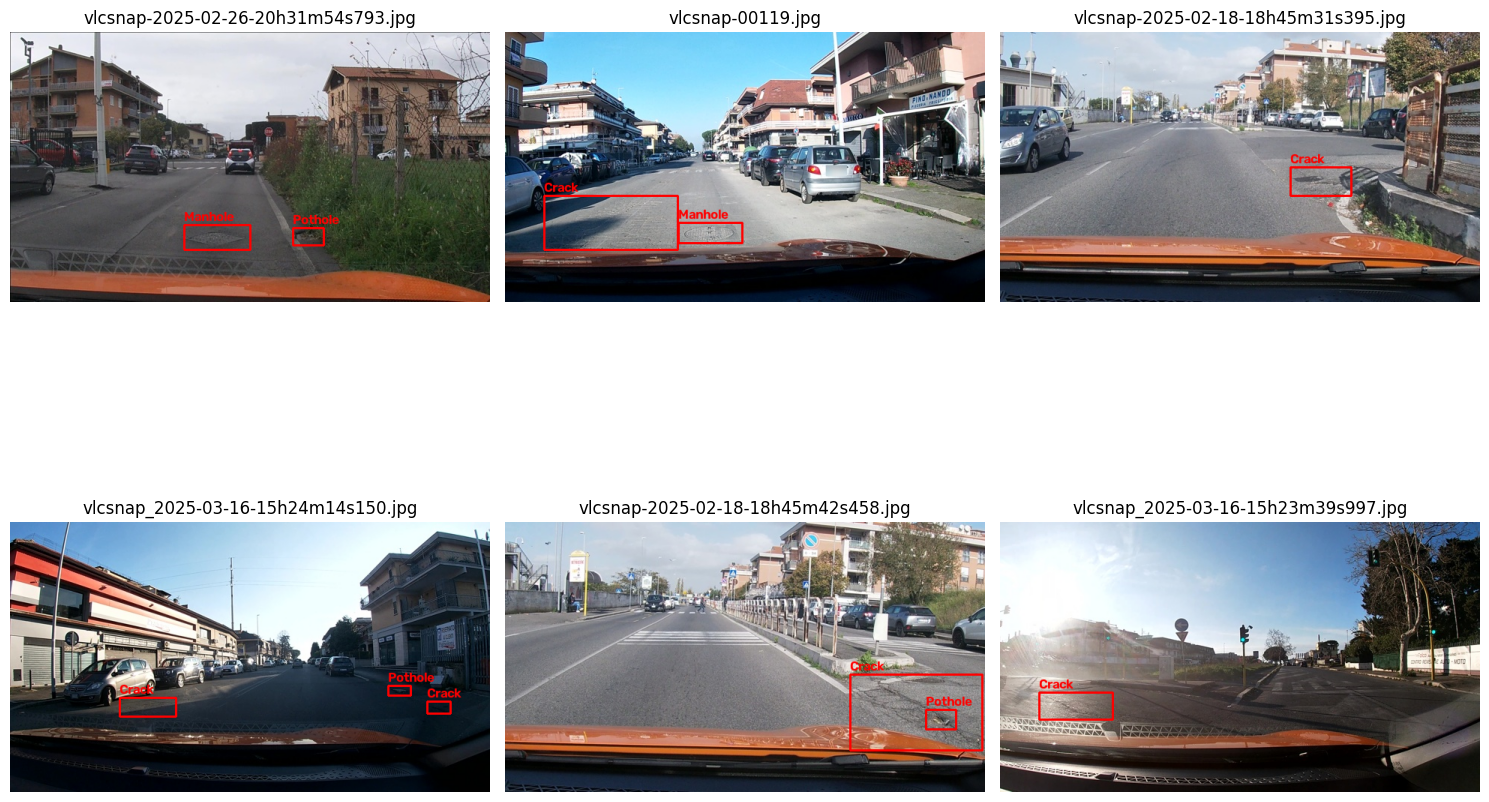

In [15]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Class names
class_names = {
    0: "Pothole",
    1: "Crack",
    2: "Manhole"
}

# Select 6 random label files
sample_labels = random.sample(label_files, 6)

plt.figure(figsize=(15, 12))

for i, label_file in enumerate(sample_labels):

    # Corresponding image name
    image_name = os.path.splitext(label_file)[0] + ".jpg"
    image_path = os.path.join(images_path, image_name)
    label_path = os.path.join(labels_path, label_file)

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width, _ = image.shape

    # Read annotations
    with open(label_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    # Draw each annotation
    for line in lines:

        values = line.split()

        class_id = int(values[0])
        coordinates = list(map(float, values[1:]))

        # Convert normalized coordinates to pixel coordinates
        x_coords = coordinates[0::2]
        y_coords = coordinates[1::2]

        x_min = int(min(x_coords) * width)
        x_max = int(max(x_coords) * width)

        y_min = int(min(y_coords) * height)
        y_max = int(max(y_coords) * height)

        # Draw bounding box
        cv2.rectangle(
            image,
            (x_min, y_min),
            (x_max, y_max),
            (255, 0, 0),
            2
        )

        cv2.putText(
            image,
            class_names[class_id],
            (x_min, max(y_min - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_name)

plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import os
from collections import Counter

image_dimensions = []

for image_file in image_files:
    image_path = os.path.join(images_path, image_file)

    try:
        with Image.open(image_path) as img:
            image_dimensions.append(img.size)
    except:
        pass

dimension_counts = Counter(image_dimensions)

print("Number of unique image dimensions:", len(dimension_counts))
print("\nMost common image dimensions:")

for dimension, count in dimension_counts.most_common(10):
    print(f"{dimension} → {count} images")

Number of unique image dimensions: 1

Most common image dimensions:
(640, 360) → 2025 images


In [17]:
import os
import numpy as np

box_widths = []
box_heights = []
box_areas = []

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 360

for label_file in label_files:

    label_path = os.path.join(labels_path, label_file)

    with open(label_path, 'r') as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            values = list(map(float, line.split()))

            # First value = class ID
            class_id = int(values[0])

            # Remaining values = x,y polygon coordinates
            coordinates = values[1:]

            # Separate x and y coordinates
            x_coords = coordinates[0::2]
            y_coords = coordinates[1::2]

            # Convert normalized coordinates to pixels
            x_pixels = [x * IMAGE_WIDTH for x in x_coords]
            y_pixels = [y * IMAGE_HEIGHT for y in y_coords]

            # Find bounding box around the polygon
            x_min = min(x_pixels)
            x_max = max(x_pixels)

            y_min = min(y_pixels)
            y_max = max(y_pixels)

            width = x_max - x_min
            height = y_max - y_min

            box_widths.append(width)
            box_heights.append(height)
            box_areas.append(width * height)


print("Total damage regions:", len(box_widths))

print("\nBounding-box width (pixels)")
print("--------------------------")
print("Minimum:", round(min(box_widths), 2))
print("Maximum:", round(max(box_widths), 2))
print("Average:", round(np.mean(box_widths), 2))

print("\nBounding-box height (pixels)")
print("---------------------------")
print("Minimum:", round(min(box_heights), 2))
print("Maximum:", round(max(box_heights), 2))
print("Average:", round(np.mean(box_heights), 2))

Total damage regions: 4737

Bounding-box width (pixels)
--------------------------
Minimum: 2.0
Maximum: 640.0
Average: 80.31

Bounding-box height (pixels)
---------------------------
Minimum: 0.0
Maximum: 359.0
Average: 37.91


In [18]:
zero_width = 0
zero_height = 0
very_small_boxes = 0

for width, height in zip(box_widths, box_heights):

    if width == 0:
        zero_width += 1

    if height == 0:
        zero_height += 1

    if width < 5 or height < 5:
        very_small_boxes += 1

print("Zero-width regions :", zero_width)
print("Zero-height regions:", zero_height)
print("Very small regions (<5 px in width OR height):", very_small_boxes)

Zero-width regions : 0
Zero-height regions: 1
Very small regions (<5 px in width OR height): 3


In [19]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

brightness_values = []

for image_file in image_files:

    image_path = os.path.join(images_path, image_file)

    image = cv2.imread(image_path)

    if image is not None:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        brightness_values.append(np.mean(gray))

print("Brightness statistics:")
print("----------------------")
print("Minimum:", round(min(brightness_values), 2))
print("Maximum:", round(max(brightness_values), 2))
print("Average:", round(np.mean(brightness_values), 2))

Brightness statistics:
----------------------
Minimum: 56.59
Maximum: 178.3
Average: 105.0


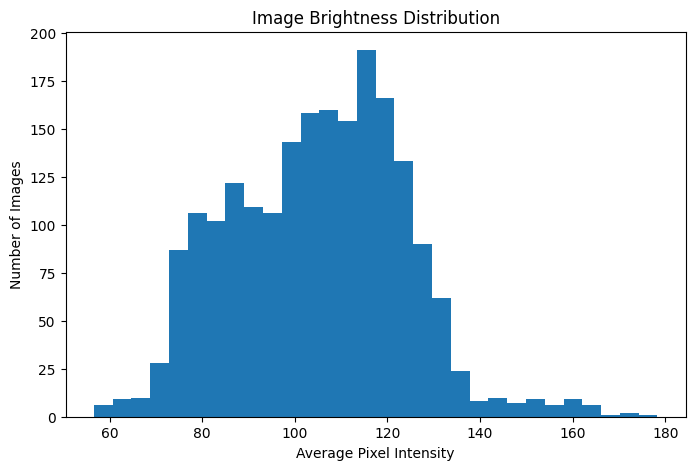

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(brightness_values, bins=30)

plt.title("Image Brightness Distribution")
plt.xlabel("Average Pixel Intensity")
plt.ylabel("Number of Images")

plt.show()

In [21]:
contrast_values = []

for image_file in image_files:

    image_path = os.path.join(images_path, image_file)

    image = cv2.imread(image_path)

    if image is not None:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        contrast_values.append(np.std(gray))

print("Contrast statistics:")
print("--------------------")
print("Minimum:", round(min(contrast_values), 2))
print("Maximum:", round(max(contrast_values), 2))
print("Average:", round(np.mean(contrast_values), 2))

Contrast statistics:
--------------------
Minimum: 24.75
Maximum: 92.87
Average: 66.64


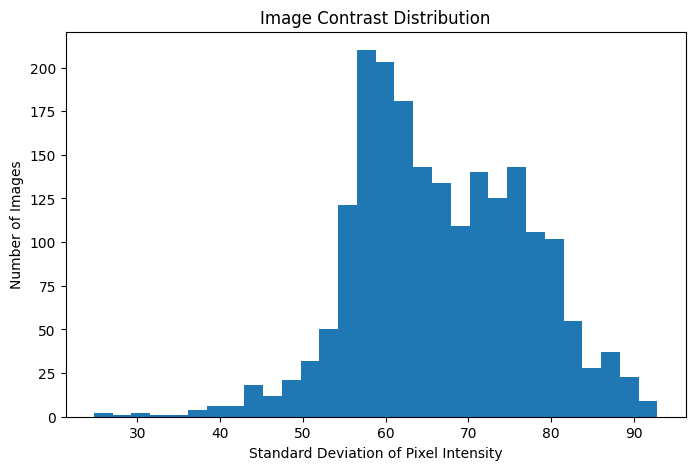

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(contrast_values, bins=30)

plt.title("Image Contrast Distribution")
plt.xlabel("Standard Deviation of Pixel Intensity")
plt.ylabel("Number of Images")

plt.show()

In [23]:
from collections import defaultdict
import os
import numpy as np

class_widths = defaultdict(list)
class_heights = defaultdict(list)

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 360

for label_file in label_files:

    label_path = os.path.join(labels_path, label_file)

    with open(label_path, 'r') as f:

        for line in f:
            line = line.strip()

            if not line:
                continue

            values = list(map(float, line.split()))

            class_id = int(values[0])
            coordinates = values[1:]

            x_coords = coordinates[0::2]
            y_coords = coordinates[1::2]

            x_pixels = [x * IMAGE_WIDTH for x in x_coords]
            y_pixels = [y * IMAGE_HEIGHT for y in y_coords]

            width = max(x_pixels) - min(x_pixels)
            height = max(y_pixels) - min(y_pixels)

            class_widths[class_id].append(width)
            class_heights[class_id].append(height)

class_names = {
    0: "Pothole",
    1: "Crack",
    2: "Manhole"
}

print("Average damage-region size by class:")
print("--------------------------------------")

for class_id in sorted(class_names):

    print(
        f"{class_names[class_id]} → "
        f"Width: {np.mean(class_widths[class_id]):.2f} px, "
        f"Height: {np.mean(class_heights[class_id]):.2f} px"
    )

Average damage-region size by class:
--------------------------------------
Pothole → Width: 54.80 px, Height: 24.49 px
Crack → Width: 101.61 px, Height: 51.26 px
Manhole → Width: 57.87 px, Height: 20.45 px


In [24]:
import os

# Output folder for our classification dataset
crop_dataset_path = '/content/road_damage_crops'

# Class folders
class_names = {
    0: 'Pothole',
    1: 'Crack',
    2: 'Manhole'
}

# Create folders
for class_id, class_name in class_names.items():
    folder = os.path.join(crop_dataset_path, class_name)
    os.makedirs(folder, exist_ok=True)

print("Classification folders created!")

print(os.listdir(crop_dataset_path))

Classification folders created!
['Pothole', 'Manhole', 'Crack']


starting of preprocessing after analysing the data using eda

In [25]:
import os
import cv2
import shutil
from google.colab import drive # Added for drive mount

# --- Code to ensure dataset is present (copied from c8fpgZmUFWWW) ---
# Ensure Google Drive is mounted
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    print("Google Drive mounted.")

source_data_path = '/content/drive/MyDrive/archive (15)/data'
destination_data_path = '/content/road_damage_data'

# Create the destination directory if it doesn't exist
os.makedirs(destination_data_path, exist_ok=True)

# Explicitly check if the source directory exists and is a directory
if not os.path.isdir(source_data_path):
    print(f"Error: Source directory not found or not a directory: {source_data_path}")
else:
    # Copy the dataset if it's not already copied or if content is missing
    # (checking if labels_path exists would be more robust, but copytree with dirs_exist_ok handles this)
    if not os.path.exists(os.path.join(destination_data_path, 'labels')):
        print(f"Copying dataset from {source_data_path} to {destination_data_path}...")
        shutil.copytree(source_data_path, destination_data_path, dirs_exist_ok=True)
        print("Dataset copied successfully!")
    else:
        print("Dataset already present in /content/road_damage_data.")
# -------------------------------------------------------------------


# Assuming these paths and files are available from previous executed cells
dataset_path = '/content/road_damage_data'
images_path = os.path.join(dataset_path, 'images')
labels_path = os.path.join(dataset_path, 'labels')

# Get label files (assuming images_path and labels_path are correctly set)
label_files = [f for f in os.listdir(labels_path) if f.lower().endswith('.txt')]

# Output folder for our classification dataset
crop_dataset_path = '/content/road_damage_crops'

# Class names
class_names = {
    0: 'Pothole',
    1: 'Crack',
    2: 'Manhole'
}

crop_count = {
    'Pothole': 0,
    'Crack': 0,
    'Manhole': 0
}

# Go through every label file
for label_file in label_files:

    # Get the corresponding image filename
    image_name_without_ext = os.path.splitext(label_file)[0]

    # Find the corresponding image
    image_path = None

    for ext in ['.jpg', '.jpeg', '.png']:
        possible_path = os.path.join(
            images_path,
            image_name_without_ext + ext
        )

        if os.path.exists(possible_path):
            image_path = possible_path
            break

    # Skip if corresponding image is not found
    if image_path is None:
        continue

    # Read the image
    image = cv2.imread(image_path)

    if image is None:
        continue

    image_height, image_width = image.shape[:2]

    # Read the label file
    label_path = os.path.join(labels_path, label_file)

    with open(label_path, 'r') as f:
        lines = f.readlines()

    # Process every damage annotation
    for damage_index, line in enumerate(lines):

        values = line.strip().split()

        if len(values) < 7:
            continue

        # First value = class ID
        class_id = int(values[0])

        # Remaining values = polygon coordinates
        polygon_values = list(map(float, values[1:]))

        # Separate x and y coordinates
        x_coords = polygon_values[0::2]
        y_coords = polygon_values[1::2]

        # Convert normalized coordinates to pixel coordinates
        x_pixels = [int(x * image_width) for x in x_coords]
        y_pixels = [int(y * image_height) for y in y_coords]

        # Find the bounding rectangle around the polygon
        x_min = max(min(x_pixels), 0)
        x_max = min(max(x_pixels), image_width)

        y_min = max(min(y_pixels), 0)
        y_max = min(max(y_pixels), image_height)

        # Skip invalid crops
        if x_max <= x_min or y_max <= y_min:
            continue

        # Crop the damage region
        crop = image[y_min:y_max, x_min:x_max]

        # Skip empty crops
        if crop.size == 0:
            continue

        # Get class name
        class_name = class_names.get(class_id)

        if class_name is None:
            continue

        # Create output filename
        crop_filename = (
            f"{image_name_without_ext}_damage_{damage_index}.jpg"
        )

        # Save the cropped damage image
        output_path = os.path.join(
            crop_dataset_path,
            class_name,
            crop_filename
        )

        # Ensure the output class directory exists
        os.makedirs(os.path.dirname(output_path), exist_ok=True)

        cv2.imwrite(output_path, crop)

        crop_count[class_name] += 1


print("Cropping completed successfully!")

print("\nNumber of crops created:")
for class_name, count in crop_count.items():
    print(f"{class_name}: {count}")

Dataset already present in /content/road_damage_data.
Cropping completed successfully!

Number of crops created:
Pothole: 1261
Crack: 2518
Manhole: 957


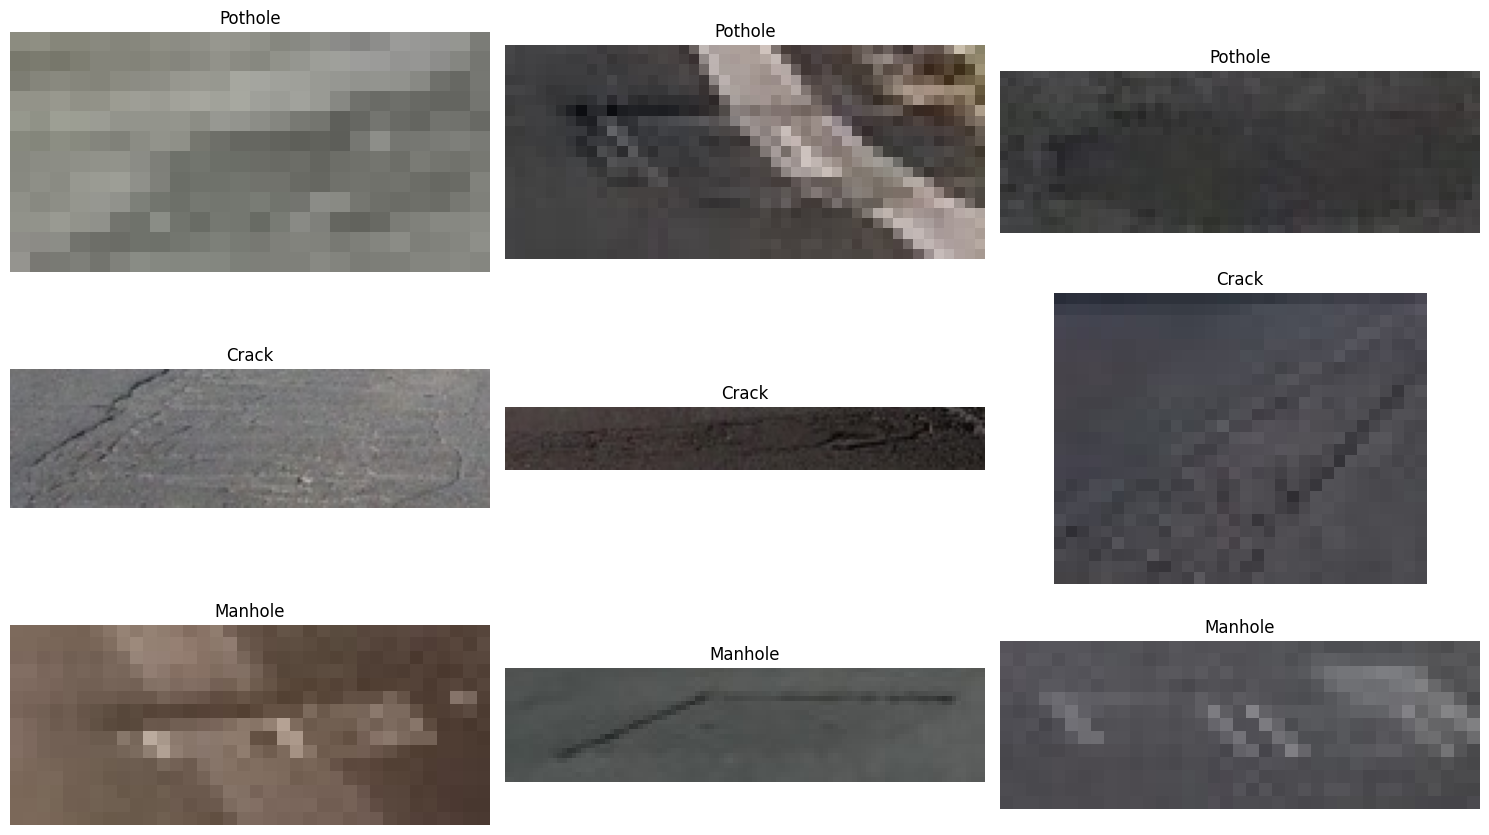

In [26]:
import os
import random
import cv2
import matplotlib.pyplot as plt

classes = ['Pothole', 'Crack', 'Manhole']

plt.figure(figsize=(15, 9))

plot_index = 1

for class_name in classes:

    class_path = os.path.join(crop_dataset_path, class_name)

    # Get all cropped images
    crop_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Select 3 random images
    selected_files = random.sample(
        crop_files,
        min(3, len(crop_files))
    )

    for crop_file in selected_files:

        image_path = os.path.join(class_path, crop_file)

        image = cv2.imread(image_path)

        # Convert BGR to RGB for matplotlib
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 3, plot_index)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()

In [27]:
import os
import cv2

# Path containing our cropped images
crop_dataset_path = '/content/road_damage_crops'

# Create a new folder for resized images
resized_dataset_path = '/content/road_damage_resized'

# Image size required for CNN
IMG_SIZE = 224

# Our classes
class_names = ['Pothole', 'Crack', 'Manhole']

# Keep track of resized images
resize_count = {
    'Pothole': 0,
    'Crack': 0,
    'Manhole': 0
}

# Go through each class
for class_name in class_names:

    # Input folder
    input_folder = os.path.join(
        crop_dataset_path,
        class_name
    )

    # Output folder
    output_folder = os.path.join(
        resized_dataset_path,
        class_name
    )

    # Create output folder
    os.makedirs(output_folder, exist_ok=True)

    # Process every cropped image
    for image_file in os.listdir(input_folder):

        # Full path of input image
        image_path = os.path.join(
            input_folder,
            image_file
        )

        # Read image
        image = cv2.imread(image_path)

        # Skip invalid images
        if image is None:
            continue

        # Resize image to 224 × 224
        resized_image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        # Output path
        output_path = os.path.join(
            output_folder,
            image_file
        )

        # Save resized image
        cv2.imwrite(
            output_path,
            resized_image
        )

        resize_count[class_name] += 1


print("Resizing completed successfully!\n")

print("Number of resized images:")

for class_name, count in resize_count.items():
    print(f"{class_name}: {count}")

Resizing completed successfully!

Number of resized images:
Pothole: 1261
Crack: 2518
Manhole: 957


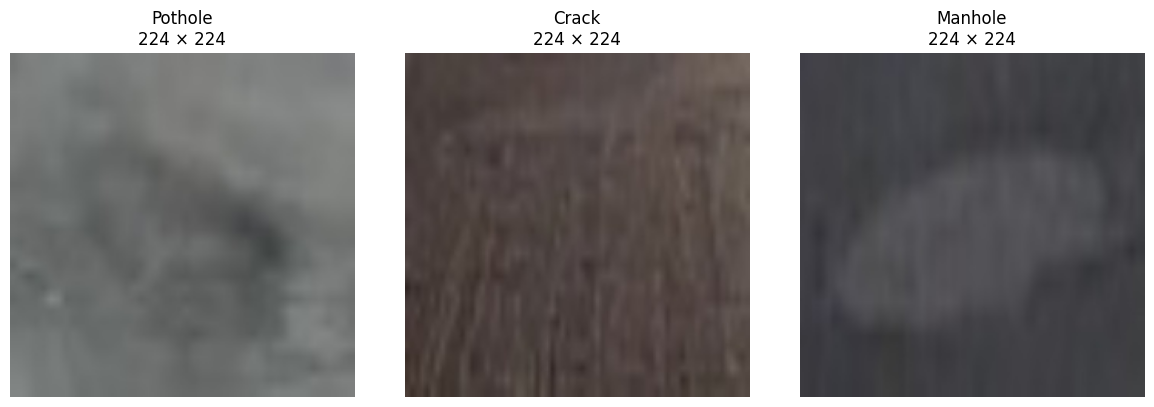

In [28]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# Display one sample from each class
class_names = ['Pothole', 'Crack', 'Manhole']

plt.figure(figsize=(12, 4))

for i, class_name in enumerate(class_names):

    # Get folder path
    class_folder = os.path.join(
        resized_dataset_path,
        class_name
    )

    # Get all images
    image_files = os.listdir(class_folder)

    # Select a random image
    selected_image = random.choice(image_files)

    # Read the image
    image_path = os.path.join(
        class_folder,
        selected_image
    )

    image = cv2.imread(image_path)

    # Convert BGR to RGB for correct display
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{class_name}\n224 × 224")
    plt.axis('off')

plt.tight_layout()
plt.show()

Before normalization:
Minimum pixel value: 56
Maximum pixel value: 147

After normalization:
Minimum pixel value: 0.2196078431372549
Maximum pixel value: 0.5764705882352941


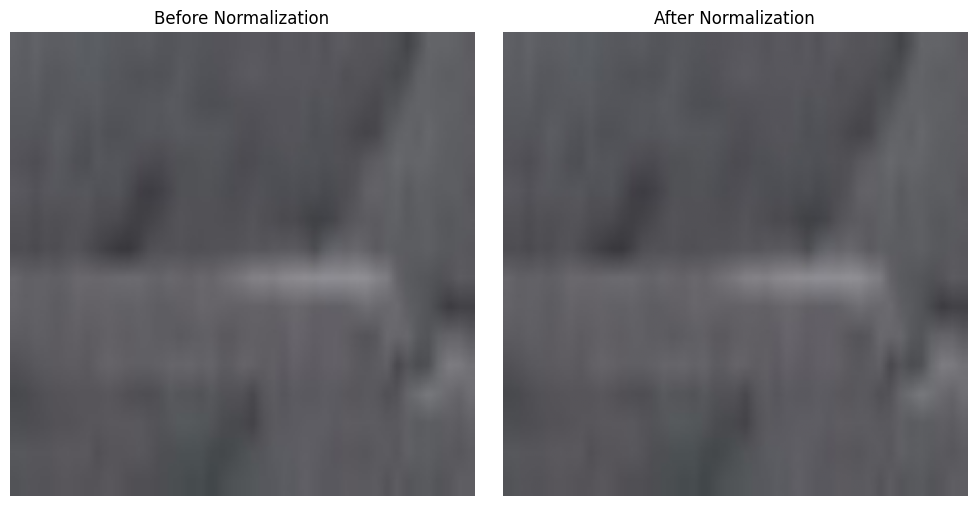

In [29]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# Select one class
class_name = 'Pothole'

# Get the class folder
class_folder = os.path.join(
    resized_dataset_path,
    class_name
)

# Select a random image
image_file = random.choice(os.listdir(class_folder))

# Read the image
image_path = os.path.join(class_folder, image_file)

image = cv2.imread(image_path)

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Normalize pixel values from 0–255 to 0–1
normalized_image = image / 255.0

# Print pixel value ranges
print("Before normalization:")
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

print("\nAfter normalization:")
print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())

# Display original and normalized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Before Normalization")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normalized_image)
plt.title("After Normalization")
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import os
import shutil
import random

# Source folder containing resized images
source_path = '/content/road_damage_resized'

# Destination folder
split_dataset_path = '/content/road_damage_split'

# Classes
classes = ['Pothole', 'Crack', 'Manhole']

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Create the main folders
for split in ['train', 'val', 'test']:
    for class_name in classes:
        folder_path = os.path.join(
            split_dataset_path,
            split,
            class_name
        )

        os.makedirs(folder_path, exist_ok=True)

print("Train, validation and test folders created!")

Train, validation and test folders created!


In [31]:
import os
import shutil
import random

# Set a random seed so the split is reproducible
random.seed(42)

# Split the images for each class
for class_name in classes:

    # Source class folder
    class_source_path = os.path.join(
        source_path,
        class_name
    )

    # Get all image filenames
    image_files = [
        f for f in os.listdir(class_source_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Randomly shuffle the images
    random.shuffle(image_files)

    # Calculate split positions
    total_images = len(image_files)

    train_end = int(train_ratio * total_images)
    val_end = train_end + int(val_ratio * total_images)

    # Split the image list
    train_images = image_files[:train_end]
    val_images = image_files[train_end:val_end]
    test_images = image_files[val_end:]

    # Copy training images
    for image_file in train_images:
        shutil.copy(
            os.path.join(class_source_path, image_file),
            os.path.join(
                split_dataset_path,
                'train',
                class_name,
                image_file
            )
        )

    # Copy validation images
    for image_file in val_images:
        shutil.copy(
            os.path.join(class_source_path, image_file),
            os.path.join(
                split_dataset_path,
                'val',
                class_name,
                image_file
            )
        )

    # Copy testing images
    for image_file in test_images:
        shutil.copy(
            os.path.join(class_source_path, image_file),
            os.path.join(
                split_dataset_path,
                'test',
                class_name,
                image_file
            )
        )

    print(f"\n{class_name}:")
    print(f"Total images: {total_images}")
    print(f"Training images: {len(train_images)}")
    print(f"Validation images: {len(val_images)}")
    print(f"Testing images: {len(test_images)}")

print("\nDataset splitting completed successfully!")


Pothole:
Total images: 1261
Training images: 882
Validation images: 189
Testing images: 190

Crack:
Total images: 2518
Training images: 1762
Validation images: 377
Testing images: 379

Manhole:
Total images: 957
Training images: 669
Validation images: 143
Testing images: 145

Dataset splitting completed successfully!


In [32]:
import tensorflow as tf
from tensorflow.keras import layers

# Augmentation pipeline
augmentation = tf.keras.Sequential([

    # Slight random rotation
    layers.RandomRotation(0.1),

    # Random zoom
    layers.RandomZoom(
        height_factor=0.1,
        width_factor=0.1
    ),

    # Slight brightness adjustment
    layers.RandomBrightness(0.1),

], name="data_augmentation")

print("Augmentation pipeline created successfully!")

Augmentation pipeline created successfully!


In [33]:
import os
import numpy as np
import tensorflow as tf
import cv2

# Training folder
train_path = os.path.join(
    split_dataset_path,
    'train'
)

# Target number of images
target_count = 1762

# Classes to augment
classes_to_augment = ['Pothole', 'Manhole']

for class_name in classes_to_augment:

    class_path = os.path.join(
        train_path,
        class_name
    )

    # Get original image files
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
        and not f.startswith('aug_')
    ]

    original_count = len(image_files)

    # Number of augmented images needed
    images_needed = target_count - original_count

    print(f"\n{class_name}")
    print(f"Original images: {original_count}")
    print(f"Augmented images needed: {images_needed}")

    # Create augmented images
    for i in range(images_needed):

        # Select an original image
        image_file = image_files[
            i % original_count
        ]

        image_path = os.path.join(
            class_path,
            image_file
        )

        # Read image
        image = tf.io.read_file(image_path)
        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        # Convert to float
        image = tf.cast(image, tf.float32) / 255.0

        # Apply augmentation
        augmented_image = augmentation(
            tf.expand_dims(image, axis=0),
            training=True
        )[0]

        # Keep values between 0 and 1
        augmented_image = tf.clip_by_value(
            augmented_image,
            0.0,
            1.0
        )

        # Convert back to image format
        augmented_image = (
            augmented_image.numpy() * 255
        ).astype(np.uint8)

        # Create new filename
        output_filename = (
            f"aug_{i}_{image_file}"
        )

        output_path = os.path.join(
            class_path,
            output_filename
        )

        # Save augmented image
        cv2.imwrite(
            output_path,
            cv2.cvtColor(
                augmented_image,
                cv2.COLOR_RGB2BGR
            )
        )

    print(
        f"Augmentation completed for {class_name}!"
    )


Pothole
Original images: 882
Augmented images needed: 880
Augmentation completed for Pothole!

Manhole
Original images: 669
Augmented images needed: 1093
Augmentation completed for Manhole!


In [34]:
import os

train_path = os.path.join(
    split_dataset_path,
    'train'
)

print("Final training dataset distribution:")
print("-" * 40)

for class_name in classes:

    class_path = os.path.join(
        train_path,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]

    print(
        f"{class_name}: {len(image_files)} images"
    )

Final training dataset distribution:
----------------------------------------
Pothole: 1762 images
Crack: 1762 images
Manhole: 1762 images


In [35]:
import tensorflow as tf
import os

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Dataset paths
train_path = os.path.join(
    split_dataset_path,
    'train'
)

val_path = os.path.join(
    split_dataset_path,
    'val'
)

test_path = os.path.join(
    split_dataset_path,
    'test'
)

# Load training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load testing dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDatasets loaded successfully!")

# Display the class names
print("\nClass names:")
print(train_dataset.class_names)

Found 5286 files belonging to 3 classes.
Found 709 files belonging to 3 classes.
Found 714 files belonging to 3 classes.

Datasets loaded successfully!

Class names:
['Crack', 'Manhole', 'Pothole']


## Fix applied: missing input normalization

Diagnosis showed the training pipeline never actually normalized pixel values before feeding them to the CNN. `image_dataset_from_directory()` returns raw `[0, 255]` pixel values, and no `Rescaling` layer or `.map()` normalization step existed anywhere between loading the data and training the model.

This caused the network to saturate and collapse to predicting the majority class (`Crack`) for every input — matching the observed test accuracy of 53.08%, which is exactly `379 / 714` (the proportion of Crack images in the test set).

**The only change below is adding `layers.Rescaling(1./255, input_shape=(224, 224, 3))` as the first layer of the model.** Everything else (data pipeline, splits, augmentation, loss, architecture) is unchanged from the original notebook.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    # FIX: Normalize pixel values from [0, 255] to [0, 1].
    # image_dataset_from_directory() does NOT normalize automatically,
    # and no normalization was applied anywhere else in the pipeline.
    # Without this layer the CNN was training on raw 0-255 pixel values,
    # which caused activations to saturate and the model to collapse
    # to always predicting the majority class (Crack).
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # First Convolution Block
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),


    # Second Convolution Block
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),


    # Third Convolution Block
    layers.Conv2D(
        128,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),


    # Fourth Convolution Block
    layers.Conv2D(
        256,
        (3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D((2, 2)),


    # Convert feature maps into a single vector
    layers.Flatten(),


    # Fully Connected Layer
    layers.Dense(128, activation='relu'),


    # Dropout to reduce overfitting
    layers.Dropout(0.5),


    # Output Layer - 3 damage classes
    layers.Dense(3, activation='softmax')
])

model.summary()

print("CNN model created successfully (with Rescaling normalization layer)!")

In [41]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [42]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.4003 - loss: 3.4753 - val_accuracy: 0.5317 - val_loss: 1.0059
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4300 - loss: 1.0116 - val_accuracy: 0.5317 - val_loss: 1.0255
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4240 - loss: 1.0348 - val_accuracy: 0.5317 - val_loss: 1.0182
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.4281 - loss: 1.0167 - val_accuracy: 0.5317 - val_loss: 1.0131
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4264 - loss: 1.0109 - val_accuracy: 0.5317 - val_loss: 1.0102
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.4228 - loss: 0.9979 - val_accuracy: 0.5317 - val_loss: 1.0038
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.4361 - loss: 0.9995 - val_accuracy: 0.4993 - val_loss: 1.0141
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.4383 - loss: 0.9889 -

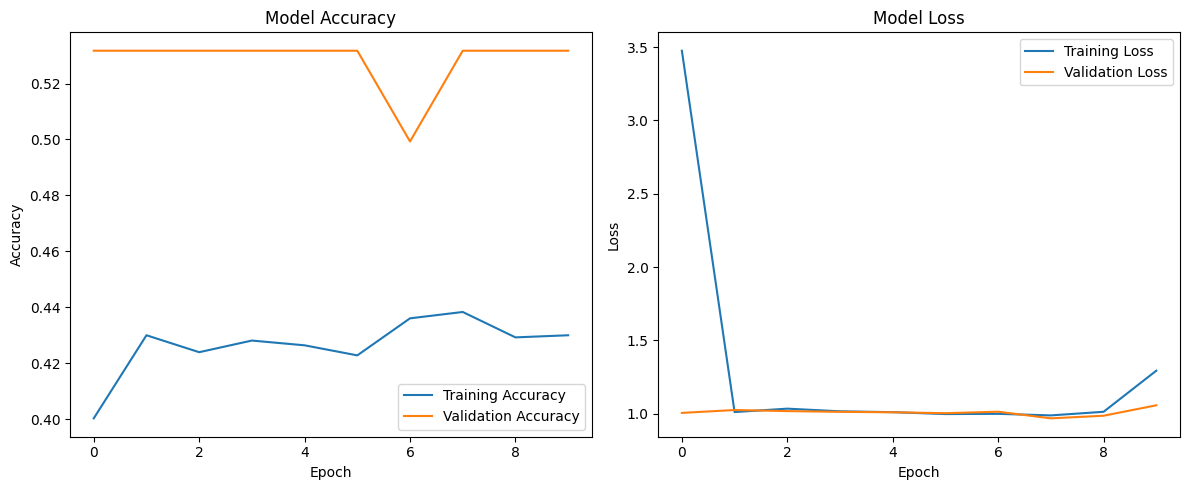

In [43]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
# Load testing dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Testing dataset loaded successfully!")

Found 714 files belonging to 3 classes.
Testing dataset loaded successfully!


In [45]:
# Evaluate the model on testing data

test_loss, test_accuracy = model.evaluate(test_dataset)

print("\nTest Results:")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5308 - loss: 1.0579

Test Results:
Test Loss: 1.0579
Test Accuracy: 53.08 %


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Store actual labels and predicted labels
true_labels = []
predicted_labels = []

# Go through the test dataset
for images, labels in test_dataset:

    # Get predictions from the trained CNN
    predictions = model.predict(images, verbose=0)

    # Get the class with the highest predicted probability
    predicted_classes = np.argmax(predictions, axis=1)

    # Store actual and predicted labels
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)

# Convert lists to NumPy arrays
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

print("Actual labels collected:", len(true_labels))
print("Predicted labels collected:", len(predicted_labels))

Actual labels collected: 714
Predicted labels collected: 714


<Figure size 700x600 with 0 Axes>

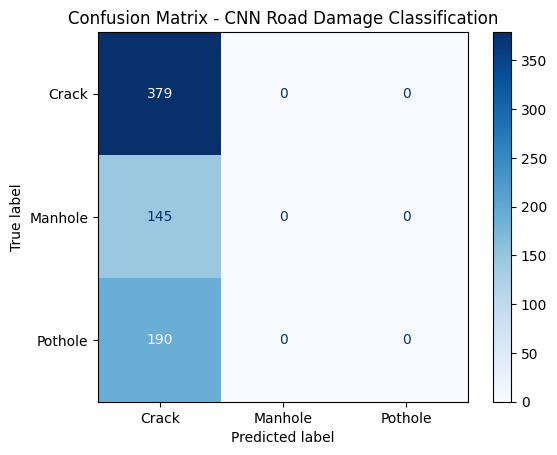

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display it
class_names = test_dataset.class_names

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(7, 6))

disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix - CNN Road Damage Classification")
plt.show()

In [48]:
import os

# Count images in each training class
for class_name in sorted(os.listdir(train_path)):

    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"{class_name}: {image_count} images")

Crack: 1762 images
Manhole: 1762 images
Pothole: 1762 images


In [49]:
# Take one batch of test images
for images, labels in test_dataset.take(1):

    # Get predictions
    predictions = model.predict(images, verbose=0)

    # Display first 10 predictions
    for i in range(10):

        print(f"\nImage {i+1}")
        print("True class:", class_names[labels[i]])

        print("Prediction probabilities:")

        for j, class_name in enumerate(class_names):
            print(f"{class_name}: {predictions[i][j]:.4f}")

        predicted_class = np.argmax(predictions[i])
        print("Predicted class:", class_names[predicted_class])


Image 1
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 2
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 3
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 4
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 5
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 6
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 7
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 8
True class: Crack
Prediction probabilities:
Crack: 0.3853
Manhole: 0.2970
Pothole: 0.3178
Predicted class: Crack

Image 9
True class: Cra